In [23]:
import yfinance as yf
import pandas as pd

# 10 stocks across sectors (you can change these)
tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'ITC.NS',
           'WIPRO.NS', 'SBIN.NS', 'MARUTI.NS', 'SUNPHARMA.NS', 'HINDUNILVR.NS']

# Pull 5 years of adjusted closing prices
data = yf.download(tickers, start='2019-01-01', end='2024-01-01')['Close']
data.dropna(inplace=True)

print(data.shape)  # Should be ~1250 rows × 10 columns
data.head(10)

[*********************100%***********************]  10 of 10 completed


(1235, 10)


Ticker,HDFCBANK.NS,HINDUNILVR.NS,INFY.NS,ITC.NS,MARUTI.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TCS.NS,WIPRO.NS
Date,,,,,,,,,,
2019-01-01,504.392487,1607.500366,541.725830,196.502686,7004.461914,496.196442,271.551147,402.755890,1561.000244,112.147346
2019-01-02,499.790283,1592.774170,544.984131,195.043015,6808.711914,489.733887,266.384796,408.794250,1577.818359,111.769699
2019-01-03,495.868988,1596.165527,545.065552,193.826584,6748.849121,483.691864,263.846954,405.124786,1558.661987,111.752518
2019-01-04,497.195618,1590.185913,538.467529,195.286270,6777.469238,486.303467,269.783722,402.988159,1539.711670,111.392014
2019-01-07,497.946930,1593.086670,547.142700,195.772858,6896.960938,489.003540,268.560059,400.201141,1556.980957,111.323364
2019-01-08,493.802582,1580.502319,545.798706,197.580048,6969.518555,488.959290,276.717529,416.226013,1553.412231,111.769699
2019-01-09,497.042999,1593.131226,550.726746,201.854904,7019.544434,491.659363,276.717529,416.876251,1547.997559,112.954163
2019-01-10,495.094055,1594.202393,553.659241,201.298859,6924.644531,490.220764,276.944092,413.021027,1549.310181,111.838356
2019-01-11,495.892334,1579.208008,556.754578,205.295593,6858.036133,486.037872,274.406281,412.835236,1511.573120,112.851158


In [24]:
import numpy as np

# Daily returns
returns = data.pct_change().dropna() # pct_change = percentage change from previous data

# --- Annualised metrics per stock ---
trading_days = 252

summary = pd.DataFrame()
summary['CAGR (%)'] = ((data.iloc[-1] / data.iloc[0]) ** (1/5) - 1) * 100 # time = 5 years
summary['Annual Volatility (%)'] = returns.std() * np.sqrt(trading_days) * 100
summary['Sharpe Ratio'] = (returns.mean() * trading_days) / (returns.std() * np.sqrt(trading_days))

# Max Drawdown
def max_drawdown(price_series):
    roll_max = price_series.cummax()
    drawdown = (price_series - roll_max) / roll_max
    return drawdown.min() * 100

summary['Max Drawdown (%)'] = data.apply(max_drawdown)

print(summary.round(2))

               CAGR (%)  Annual Volatility (%)  Sharpe Ratio  Max Drawdown (%)
Ticker                                                                        
HDFCBANK.NS       10.52                  26.87          0.51            -41.05
HINDUNILVR.NS      9.76                  23.59          0.52            -30.46
INFY.NS           21.29                  28.75          0.83            -36.55
ITC.NS            15.08                  26.16          0.68            -51.11
MARUTI.NS          7.59                  31.41          0.39            -48.05
RELIANCE.NS       20.81                  30.41          0.79            -45.09
SBIN.NS           17.50                  34.06          0.65            -59.49
SUNPHARMA.NS      24.99                  28.10          0.95            -31.30
TCS.NS            17.43                  24.79          0.79            -27.21
WIPRO.NS          14.47                  28.29          0.63            -50.02


In [25]:
# Define 3 allocation strategies
portfolios = {
    'Aggressive':     [0.20, 0.15, 0.10, 0.15, 0.05, 0.10, 0.05, 0.10, 0.05, 0.05],
    'Moderate':       [0.12, 0.12, 0.12, 0.12, 0.10, 0.10, 0.10, 0.10, 0.06, 0.06],
    'Conservative':   [0.05, 0.10, 0.20, 0.10, 0.15, 0.05, 0.15, 0.05, 0.10, 0.05],
}

portfolio_results = {}
for name, weights in portfolios.items():
    w = np.array(weights)
    port_return = np.dot(returns.mean(),w) * trading_days * 100
    port_vol = np.sqrt(w @returns.cov() * trading_days @ w) * 100
    port_sharpe = port_return / port_vol
    portfolio_results[name] = {
        'Annual Return (%)': round(port_return,2),
        'Annual Volatility (%)': round(port_vol,2),
        'Sharpe Ratio' : round(port_sharpe,2)
        
    }
    pd.DataFrame(portfolio_results).T

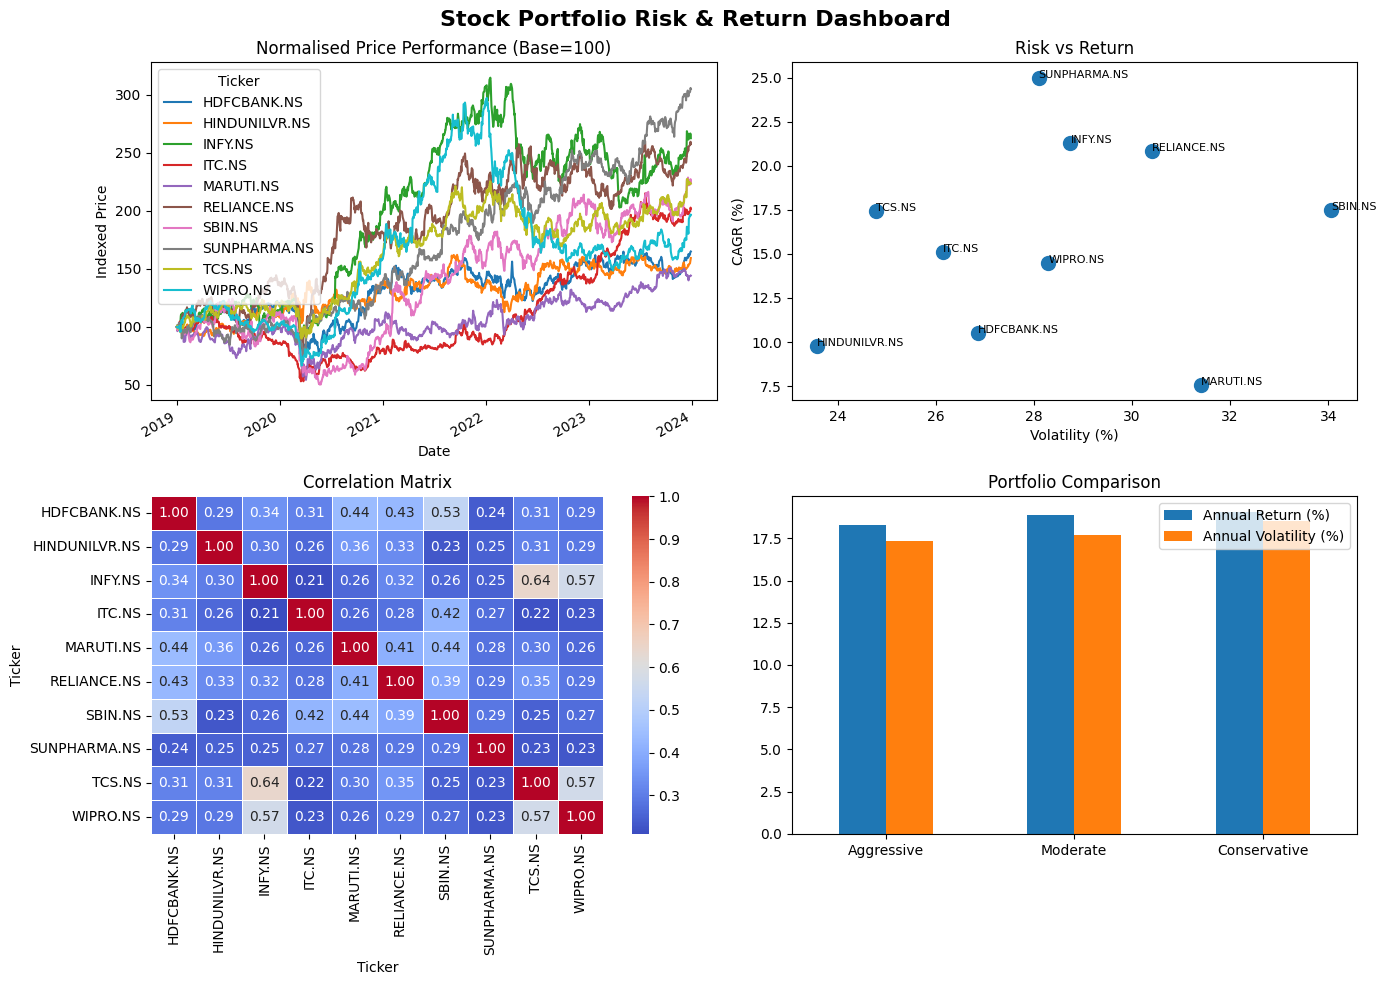

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Stock Portfolio Risk & Return Dashboard', fontsize=16, fontweight='bold')

# 1. Normalised price performance
(data / data.iloc[0] * 100).plot(ax=axes[0,0], legend=True)
axes[0,0].set_title('Normalised Price Performance (Base=100)')
axes[0,0].set_ylabel('Indexed Price')

# 2. Risk vs Return scatter
axes[0,1].scatter(summary['Annual Volatility (%)'], summary['CAGR (%)'], s=100)
for i, txt in enumerate(summary.index):
    axes[0,1].annotate(txt, (summary['Annual Volatility (%)'].iloc[i], summary['CAGR (%)'].iloc[i]), fontsize=8)
axes[0,1].set_xlabel('Volatility (%)')
axes[0,1].set_ylabel('CAGR (%)')
axes[0,1].set_title('Risk vs Return')

# 3. Correlation heatmap
sns.heatmap(returns.corr().round(2), annot=True, cmap='coolwarm', ax=axes[1,0], fmt='.2f', linewidths=0.5)
axes[1,0].set_title('Correlation Matrix')

# 4. Portfolio comparison bar chart
port_df = pd.DataFrame(portfolio_results).T
port_df[['Annual Return (%)', 'Annual Volatility (%)']].plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Portfolio Comparison')
axes[1,1].set_xticklabels(['Aggressive', 'Moderate', 'Conservative'], rotation=0)

plt.tight_layout()
plt.savefig('portfolio_dashboard.png', dpi=150)
plt.show()

In [32]:
!pip install openpyxl
with pd.ExcelWriter('portfolio_dashboard.xlsx', engine='openpyxl') as writer:
    data.to_excel(writer, sheet_name='Price Data')
    returns.to_excel(writer, sheet_name='Daily Returns')
    summary.round(2).to_excel(writer, sheet_name='Stock Metrics')
    pd.DataFrame(portfolio_results).T.to_excel(writer, sheet_name='Portfolio Summary')


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy

In [33]:
import os
print(os.getcwd())


C:\Users\HP
